Using Colab cache for faster access to the 'wine-quality-dataset' dataset.
Path to dataset files: /kaggle/input/wine-quality-dataset
Dimensões originais: 1143 linhas e 13 colunas.

Contagem de valores nulos por coluna:


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


 125 registros duplicados reais removidos para governança do pipeline.

 Distribuição da variável alvo (qualidade binária):


,count
quality_binary,
0,881
1,137


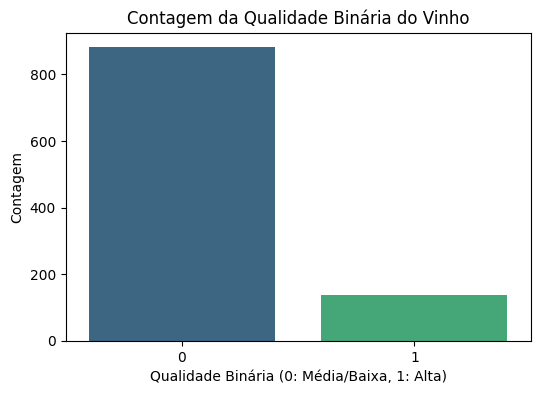


Visualização das primeiras linhas das variáveis prontas para os Modelos (Frente B):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.510499,0.909227,-1.370507,-0.475125,-0.230739,-0.457043,-0.372294,0.574517,1.258719,-0.578153,-0.961563
1,-0.280676,1.892418,-1.370507,0.057517,0.223040,0.919349,0.624466,0.052448,-0.707068,0.138438,-0.596108
2,-0.280676,1.236957,-1.166564,-0.170758,0.099282,-0.063788,0.231803,0.156862,-0.326593,-0.040710,-0.596108
3,1.672822,-1.384886,1.484700,-0.475125,-0.251365,0.132839,0.413032,0.678931,-0.960718,-0.458721,-0.596108
4,-0.510499,0.690740,-1.370507,-0.551216,-0.251365,-0.260415,-0.191065,0.574517,1.258719,-0.578153,-0.961563


In [5]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

path = kagglehub.dataset_download("yasserh/wine-quality-dataset")
print("Path to dataset files:", path)

wine_path = os.path.join(path, 'WineQT.csv')
wine_df = pd.read_csv(wine_path)
print(f"Dimensões originais: {wine_df.shape[0]} linhas e {wine_df.shape[1]} colunas.\n")

# verificação de valores nulos
print("Contagem de valores nulos por coluna:")
display(wine_df.isnull().sum())

# remoção de duplicatas
features_para_checar = wine_df.drop(columns=['Id'], errors='ignore').columns
duplicated_count = wine_df.duplicated(subset=features_para_checar).sum()

if duplicated_count > 0:
    wine_df = wine_df.drop_duplicates(subset=features_para_checar)
    print(f" {duplicated_count} registros duplicados reais removidos para governança do pipeline.")

# vinho de alta qualidade: nota >= 7 | baixa/média: nota < 7
if 'quality_binary' not in wine_df.columns:
    wine_df['quality_binary'] = wine_df['quality'].apply(lambda x: 1 if x >= 7 else 0)

print("\n Distribuição da variável alvo (qualidade binária):")
display(wine_df['quality_binary'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='quality_binary', data=wine_df, hue='quality_binary', palette='viridis', legend=False)
plt.title('Contagem da Qualidade Binária do Vinho')
plt.xlabel('Qualidade Binária (0: Média/Baixa, 1: Alta)')
plt.ylabel('Contagem')
plt.show()

# separando as variáveis preditoras (x) do alvo binário (y)
# removemos 'quality' (alvo antigo), 'quality_binary' (alvo novo) e 'id' (não preditivo)
X = wine_df.drop(columns=['quality', 'quality_binary', 'Id'], errors='ignore')
y = wine_df['quality_binary']

# aplicando (média = 0, desvio padrão = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nVisualização das primeiras linhas das variáveis prontas para os Modelos (Frente B):")
display(X_scaled_df.head())

!pip freeze > requirements.txt

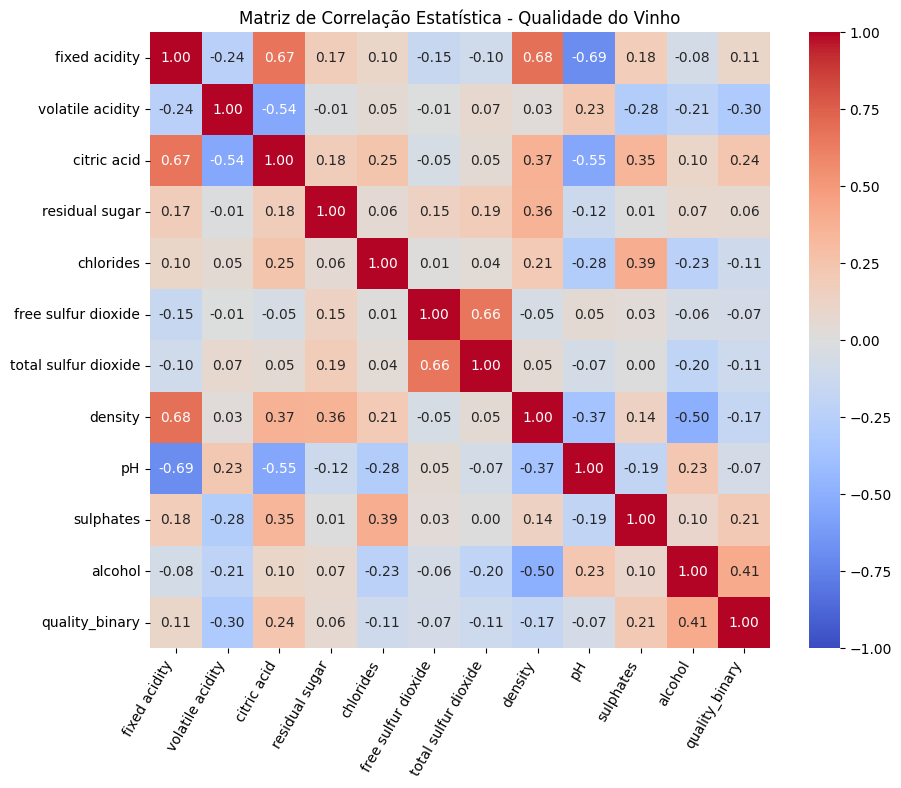

Gráfico gerado com sucesso e salvo na pasta 'results'!


In [15]:
# Unindo as características químicas padronizadas com a coluna de qualidade
dados_analise = X_scaled_df.copy()
dados_analise['quality_binary'] = y.values

# Calculando a correlação entre todas as colunas
matriz_correlacao = dados_analise.corr()

# Configurando o tamanho e exibindo o mapa de calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlação Estatística - Qualidade do Vinho')

plt.xticks(rotation=60, ha='right') # Inclina a legenda inferior em 75 graus e alinha à direita
plt.yticks(rotation=0)             # Deixa a legenda da lateral perfeitamente deitada (horizontal)

# Salvando o gráfico na pasta 'results'
caminho_salvar = os.path.join('..', 'results', 'matriz_correlacao.png')
plt.savefig(caminho_salvar, bbox_inches='tight')
plt.show()

print("Gráfico gerado com sucesso e salvo na pasta 'results'!")

In [16]:
# Isolando a coluna de qualidade e ordenando as correlações do maior para o menor
influenciadores = matriz_correlacao['quality_binary'].sort_values(ascending=False)

print("Influência de cada componente químico na Alta Qualidade (Nota >= 7):")
print("-" * 65)
print(influenciadores)

Influência de cada componente químico na Alta Qualidade (Nota >= 7):
-----------------------------------------------------------------
quality_binary          1.000000
alcohol                 0.410331
citric acid             0.237369
sulphates               0.213071
fixed acidity           0.107952
residual sugar          0.064405
pH                     -0.065270
free sulfur dioxide    -0.067319
chlorides              -0.105595
total sulfur dioxide   -0.114990
density                -0.166497
volatile acidity       -0.302343
Name: quality_binary, dtype: float64


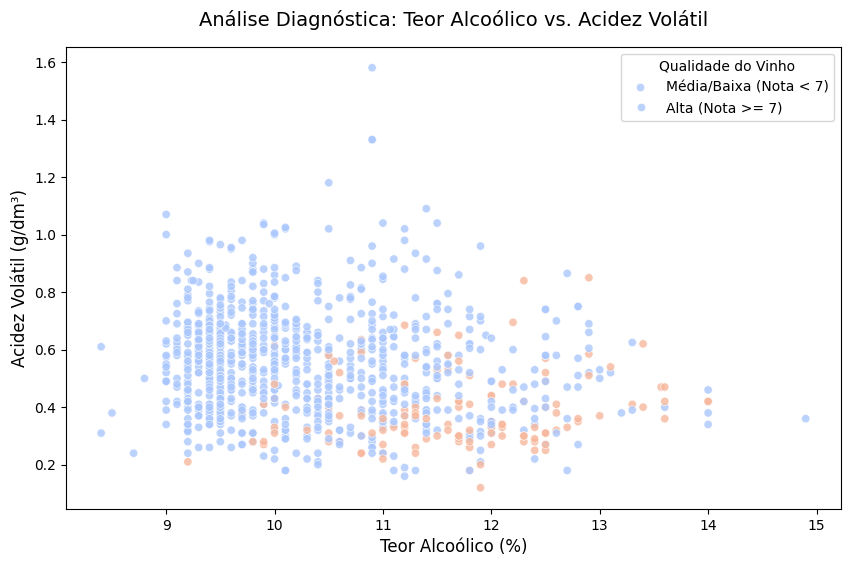

Gráfico de dispersão gerado com sucesso e salvo na pasta 'results'!


In [17]:
# Criando o gráfico de Dispersão Diagnóstico

# Configurando o tamanho do gráfico
plt.figure(figsize=(10, 6))

# Criando o gráfico de dispersão cruzando os dois principais influenciadores
# Usamos os dados brutos (wine_df) para as legendas ficarem com os valores reais de negócio
sns.scatterplot(
    x='alcohol', 
    y='volatile acidity', 
    hue='quality_binary', 
    data=wine_df, 
    palette='coolwarm', 
    alpha=0.8
)

# Customizando os títulos e legendas para uma linguagem executiva
plt.title('Análise Diagnóstica: Teor Alcoólico vs. Acidez Volátil', fontsize=14, pad=15)
plt.xlabel('Teor Alcoólico (%)', fontsize=12)
plt.ylabel('Acidez Volátil (g/dm³)', fontsize=12)

# Ajustando a legenda lateral do gráfico
plt.legend(title='Qualidade do Vinho', labels=['Média/Baixa (Nota < 7)', 'Alta (Nota >= 7)'])

# Salvando o gráfico na pasta 'results'
caminho_salvar_scatter = os.path.join('..', 'results', 'dispersao_alcohol_vs_acidez.png')
plt.savefig(caminho_salvar_scatter, bbox_inches='tight')
plt.show()

print("Gráfico de dispersão gerado com sucesso e salvo na pasta 'results'!")